# Glacier Hydraulic Tremor
This script aims to isolate subglacial hydraulic tremor from broadband seismometer data next to the calving front of Eqaloorutsit Kangilliit Sermiat. The challenge is, that 1-2 calving events per minute are dominating the recorded seismic power.

In [24]:
import obspy
from obspy.core import UTCDateTime
from obspy.clients.filesystem.sds import Client
import numpy as np
import matplotlib.pyplot as plt
import datetime
import pandas as pd

## Workflow
1. Read one day of data from one station.
2. Calculate Spectrogram with NFFT=5s.
3. Integrate over frequency band in which subglacial tremor is found.
4. Take minimum value over 10 min chunks to not be affected by calving events.
5. Do a rolling median to suppress noise.

In [25]:
# Example for July 2024
t_start = datetime.datetime(2024,7,1)
t_end = datetime.datetime(2024,7,30)

# List of seismometer stations to use
stations = ['QJT01', 'QJT02', 'QJT03']

# Times when valid seismometer data starts
start_dict = {'QJT01': datetime.datetime(2023,8,11,19),
             'QJT02': datetime.datetime(2023,8,14,19),
             'QJT03': datetime.datetime(2023,8,2,16)}

# Only looking at the vertical component
component = 'Z'

# Frequency range in which subglacial tremor is suspected (may be 3-30Hz)
freqmin = 5
freqmax = 10

# Path to the data !!! needs to be adjusted !!!
client = Client('/Volumes/DG_DATA/DG_DATA/GreenFjord_DATA/level1/seismic/QJT_data/')

In [26]:
# Extract glacier hydraulic tremor signal from seismometer data with strong calving events.

GHT_dict = {}

for sta in stations:
    print('\n'+sta)
    t_list = []  # timestamps
    min_list = []  # integrated power in frequency band used for minimum search
    Pxx_min_list = []  # entire PSD at minimum

    # Set start time to the very beginning
    t_start_loop = t_start
    while t_start_loop<t_end:
        print(t_start_loop, end='\r')
        
        # Read data
        st = client.get_waveforms('XH', sta, '', '*'+component,
                                     UTCDateTime(t_start_loop), 
                                     UTCDateTime(t_start_loop+datetime.timedelta(days=1)))
        st.merge(fill_value=0)  # fills data gaps and makes handling easier
        if len(st)>0 and st[0].stats.npts>1:  # only do the analysis if data is present
            
            # Remove data when people were present at station
            if st[0].stats.starttime.date == start_dict[sta].date():
                st.trim(UTCDateTime(start_dict[sta]), st[0].stats.endtime)
              
            # Calculate spectrogram
            Fs = st[0].stats.sampling_rate
            NFFT = 5*Fs  # 5s bins for FFT
            Pxx, freqs, bins, _ = plt.specgram(st[0].data, NFFT=int(NFFT), Fs=Fs, noverlap=0)
            plt.close()
    
            # Select relevant data for minimum power detection
            idx_low = (np.abs(freqs - freqmin)).argmin()
            idx_high = (np.abs(freqs - freqmax)).argmin()
            Pxx_cut = Pxx[idx_low:idx_high]
            freqs_cut = freqs[idx_low:idx_high]
        
            # Integrate over selected frequency band
            Pxx_int = np.sum(Pxx_cut, axis=0)
        
            # Define chunk size in bins
            chunk_size = int(10*60 / (NFFT/Fs))  # 10min
            
            # Calculate how much padding is needed (if len(bins)%chunk_size!=0)
            padding_length = chunk_size - (len(Pxx_int) % chunk_size)
            if padding_length != chunk_size:  # Only pad if necessary
                Pxx_int = np.pad(Pxx_int, (0, padding_length), constant_values=np.nan)
                bins = np.pad(bins, (0, padding_length), constant_values=np.nan)
                Pxx = np.pad(Pxx, pad_width=((0, 0), (0, padding_length)), constant_values=np.nan)
    
            # Reshape into chunks
            reshaped_data = Pxx_int.reshape(-1, chunk_size)
            reshaped_bins = bins.reshape(-1, chunk_size)
            Pxx = Pxx.reshape(Pxx.shape[0], int(Pxx.shape[1]/chunk_size), -1).transpose(1,0,2)
            
            # Calculate the minimum of each chunk
            min_values = np.nanmin(reshaped_data, axis=1)
            min_idx = np.argmin(reshaped_data, axis=1)
            
            # Get PSD with minimum power
            Pxx_select = Pxx[np.arange(Pxx.shape[0]),:,min_idx].T
            
            # Fake timestamp of chunk (center of bin)
            t_stamps = [(st[0].stats.starttime+t).datetime for t in np.nanmean(reshaped_bins, axis=1)]

            # Append to lists
            min_list.append(min_values)
            t_list.append(t_stamps)
            Pxx_min_list.append(Pxx_select)

        # Continue in while loop
        t_start_loop+=datetime.timedelta(days=1)

    # Convert list of arrays to array
    t_all = np.concatenate(t_list)
    min_all = np.concatenate(min_list)
    Pxx_all = np.concatenate(Pxx_min_list, axis=1)

    # Save results for each station into dictionary
    GHT_dict[sta] = {'t': t_all,
                     'GHT': min_all,
                     'PSD': Pxx_all}


QJT01


/Users/graeffd/opt/miniconda3/envs/master/lib/python3.10/site-packages/matplotlib/axes/_axes.py:7939: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


2024-07-29 00:00:00
QJT02
2024-07-29 00:00:00
QJT03


In [27]:
# Calculate mean GHT between stations
df_list = []

# Put GHT data into DataFrames
for sta in GHT_dict.keys():
    t = GHT_dict[sta]['t'].copy()
    GHT = GHT_dict[sta]['GHT'].copy()
    df = pd.DataFrame(data=GHT, index=t, columns=[sta])
    df = df.iloc[:-2] # remove some data when humans were reading out data at the station
    df_list.append(df)

# Merge the three DataFrames into a single one
df_ght = pd.concat(df_list, axis='columns')

# Normalization
df_ght = df_ght.divide(df_ght.median(skipna=True))

# Rolling averaging for each station
df_ght = df_ght.rolling('6h', center=True).median()

# Mean between stations
df_ght['mean'] = df_ght.mean(axis='columns')

# Setting GHT relative to minimum power
df_ght = df_ght / np.nanmin(df_ght['mean'])

# Standard Deviation
df_ght['std'] = df_ght[stations].std(axis='columns')

Text(0.5, 0, 'Time')

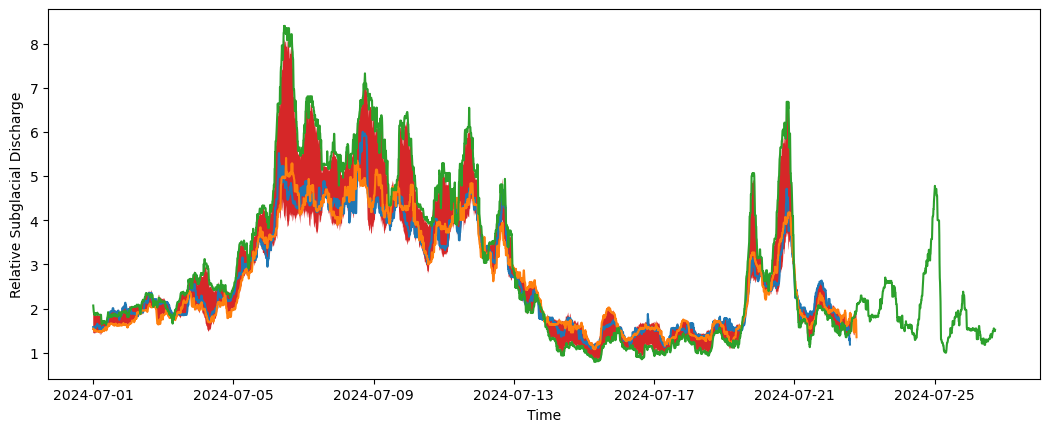

In [28]:
fig = plt.figure(figsize=(2*6.4,4.8))
for sta in stations:
    plt.plot(df_ght.index, df_ght[sta])
    plt.fill_between(df_ght.index, df_ght[sta], df_ght[sta])
plt.fill_between(df_ght.index, df_ght['mean']-df_ght['std'], df_ght['mean']+df_ght['std'])
plt.ylabel('Relative Subglacial Discharge')
plt.xlabel('Time')